# Detection on nordic country side objects including animals

First, prepare data set by
* Downloading dataset of coco subset and handpicked nordic animals, including bounding boxes
* Plotting distribution of image label classes

In [5]:
COCO_CLASSES = [
    "bird",
    "cat",
    "dog",
]

DEER_CLASSES = [
    "boar",
    "elk",
    "moose",
    "deer",
    "fox"
]

CLASSES = COCO_CLASSES + [
    cls for cls in DEER_CLASSES
    if cls not in COCO_CLASSES
]

BACKGROUND_CLASS = "Background"

EVALUATION_CLASSES = CLASSES + [BACKGROUND_CLASS]

n_detection_classes = len(CLASSES)
n_evaluation_classes = len(EVALUATION_CLASSES)

BACKGROUND_INDEX = n_detection_classes

In [6]:
import json
import shutil
import collections
import numpy as np
from pathlib import Path
from tqdm.auto import tqdm

data_root = Path("datasets")
coco_root = data_root / "coco"
coco_cache_metadata_path = coco_root / "preprocessing_metadata.json"

subset_path = Path(
    "/kaggle/input/datasets/abdelrahmanelgharibx/coco2017-subset"
)
original_images_folder = subset_path / "coco"

coco_tmp_images = coco_root / "tmp" / "images"
coco_tmp_labels = coco_root / "tmp" / "labels"

sample_size = 10000
seed = 0
balance_alpha = 1.0

coco_preprocessing_config = {
    "sample_size": sample_size,
    "seed": seed,
    "balance_alpha": balance_alpha,
    "strategy": "train_weighted_val_all_v2",
}

if list(CLASSES[:len(COCO_CLASSES)]) != list(COCO_CLASSES):
    raise ValueError("COCO_CLASSES must be the first classes in CLASSES.")


def counter_to_json(counter):
    return {str(k): int(v) for k, v in counter.items()}


def json_to_counter(data):
    return collections.Counter({
        int(k): int(v) for k, v in data.items()
    })


def save_coco_cache_metadata():
    metadata = {
        "completed": True,
        "classes": list(COCO_CLASSES),
        "config": coco_preprocessing_config,
        "instance_counts": counter_to_json(coco_instance_counts),
        "image_counts": counter_to_json(coco_image_counts),
    }

    coco_cache_metadata_path.write_text(
        json.dumps(metadata, indent=2)
    )


def load_coco_cache_metadata():
    metadata = json.loads(coco_cache_metadata_path.read_text())

    instance_counts = json_to_counter(metadata["instance_counts"])
    image_counts = json_to_counter(metadata["image_counts"])

    return instance_counts, image_counts


def coco_cache_is_valid():
    if not coco_cache_metadata_path.exists():
        return False

    if not coco_tmp_images.is_dir() or not coco_tmp_labels.is_dir():
        return False

    try:
        metadata = json.loads(coco_cache_metadata_path.read_text())
    except (OSError, json.JSONDecodeError):
        return False

    if not metadata.get("completed"):
        return False

    if metadata.get("classes") != list(COCO_CLASSES):
        return False

    if metadata.get("config") != coco_preprocessing_config:
        return False

    image_stems = {
        p.stem for p in coco_tmp_images.iterdir()
        if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
    }

    label_stems = {
        p.stem for p in coco_tmp_labels.glob("*.txt")
    }

    return bool(image_stems) and image_stems == label_stems


use_cached_coco = coco_cache_is_valid()

coco_instance_counts = collections.Counter()
coco_image_counts = collections.Counter()

if use_cached_coco:
    coco_instance_counts, coco_image_counts = load_coco_cache_metadata()
    print("Using cached COCO data.")
else:
    shutil.rmtree(coco_root, ignore_errors=True)
    coco_tmp_images.mkdir(parents=True, exist_ok=True)
    coco_tmp_labels.mkdir(parents=True, exist_ok=True)
    print("Preparing COCO data.")

Preparing COCO data.


In [7]:
if not use_cached_coco:
    with open(subset_path / "train2017.json") as file:
        train_json = json.load(file)

    with open(subset_path / "val2017.json") as file:
        val_json = json.load(file)

    target_name_to_yolo = {
        name: i for i, name in enumerate(COCO_CLASSES)
    }

    target_coco_id_to_yolo = {
        category["id"]: target_name_to_yolo[category["name"]]
        for category in train_json["categories"]
        if category["name"] in target_name_to_yolo
    }

    target_coco_ids = set(target_coco_id_to_yolo)

    print("COCO class mapping:")
    for category in train_json["categories"]:
        if category["id"] in target_coco_ids:
            print(
                f'{category["name"]:12s} '
                f'{category["id"]:2d} -> '
                f'{target_coco_id_to_yolo[category["id"]]}'
            )

    available_filenames = {
        p.name for p in original_images_folder.iterdir()
        if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
    }


    def build_image_records(source_json, source_split):
        annotations_by_image = collections.defaultdict(list)

        for annotation in source_json["annotations"]:
            if annotation["category_id"] in target_coco_ids:
                annotations_by_image[annotation["image_id"]].append(annotation)

        records = []

        for image in source_json["images"]:
            if image["file_name"] not in available_filenames:
                continue

            annotations = annotations_by_image.get(image["id"], [])

            if not annotations:
                continue

            present_classes = {
                target_coco_id_to_yolo[a["category_id"]]
                for a in annotations
            }

            records.append({
                "image": image,
                "annotations": annotations,
                "classes": present_classes,
                "source_split": source_split,
            })

        return records


    train_records = build_image_records(train_json, "train")
    val_records = build_image_records(val_json, "val")

    train_filenames = {
        record["image"]["file_name"] for record in train_records
    }

    val_filenames = {
        record["image"]["file_name"] for record in val_records
    }

    if train_filenames & val_filenames:
        raise ValueError("Overlapping COCO train/validation filenames.")

    if not train_records or not val_records:
        raise ValueError("Missing COCO training or validation images.")

    print(f"Available training images: {len(train_records)}")
    print(f"Available validation images: {len(val_records)}")

COCO class mapping:
bird         16 -> 0
cat          17 -> 1
dog          18 -> 2
Available training images: 4075
Available validation images: 161


In [8]:
selected_records = []

if not use_cached_coco:
    source_image_counts = collections.Counter()
    source_instance_counts = collections.Counter()

    for record in train_records:
        source_image_counts.update(record["classes"])

        for annotation in record["annotations"]:
            class_id = target_coco_id_to_yolo[annotation["category_id"]]
            source_instance_counts[class_id] += 1

    print("Available COCO training distribution:")
    for class_id, class_name in enumerate(COCO_CLASSES):
        print(
            f"{class_name:12s} "
            f"images={source_image_counts[class_id]:6d} "
            f"instances={source_instance_counts[class_id]:7d}"
        )

    rng = np.random.default_rng(seed)
    n_samples = min(sample_size, len(train_records))

    if n_samples < len(train_records):
        weights = np.array([
            max(
                source_image_counts[class_id] ** -balance_alpha
                for class_id in record["classes"]
            )
            for record in train_records
        ], dtype=float)

        weights /= weights.sum()

        indices = rng.choice(
            len(train_records),
            size=n_samples,
            replace=False,
            p=weights
        )

        selected_train_records = [
            train_records[i] for i in indices
        ]
    else:
        selected_train_records = list(train_records)

    selected_records = selected_train_records + val_records

    selected_image_counts = collections.Counter()
    selected_instance_counts = collections.Counter()

    for record in selected_train_records:
        selected_image_counts.update(record["classes"])

        for annotation in record["annotations"]:
            class_id = target_coco_id_to_yolo[annotation["category_id"]]
            selected_instance_counts[class_id] += 1

    print("\nSelected COCO training distribution:")
    for class_id, class_name in enumerate(COCO_CLASSES):
        print(
            f"{class_name:12s} "
            f"images={selected_image_counts[class_id]:6d} "
            f"instances={selected_instance_counts[class_id]:7d}"
        )

    print(f"\nSelected training images: {len(selected_train_records)}")
    print(f"Retained validation images: {len(val_records)}")
    print(f"Total selected images: {len(selected_records)}")

Available COCO training distribution:
bird         images=   936 instances=   3931
cat          images=   917 instances=   1107
dog          images=  2323 instances=   3042

Selected COCO training distribution:
bird         images=   936 instances=   3931
cat          images=   917 instances=   1107
dog          images=  2323 instances=   3042

Selected training images: 4075
Retained validation images: 161
Total selected images: 4236


In [9]:
selected_records = []

if not use_cached_coco:
    source_image_counts = collections.Counter()
    source_instance_counts = collections.Counter()

    for record in train_records:
        source_image_counts.update(record["classes"])

        for annotation in record["annotations"]:
            class_id = target_coco_id_to_yolo[annotation["category_id"]]
            source_instance_counts[class_id] += 1

    print("Available COCO training distribution:")
    for class_id, class_name in enumerate(COCO_CLASSES):
        print(
            f"{class_name:12s} "
            f"images={source_image_counts[class_id]:6d} "
            f"instances={source_instance_counts[class_id]:7d}"
        )

    rng = np.random.default_rng(seed)
    n_samples = min(sample_size, len(train_records))

    if n_samples < len(train_records):
        weights = np.array([
            max(
                source_image_counts[class_id] ** -balance_alpha
                for class_id in record["classes"]
            )
            for record in train_records
        ], dtype=float)

        weights /= weights.sum()

        indices = rng.choice(
            len(train_records),
            size=n_samples,
            replace=False,
            p=weights
        )

        selected_train_records = [
            train_records[i] for i in indices
        ]
    else:
        selected_train_records = list(train_records)

    selected_records = selected_train_records + val_records

    selected_image_counts = collections.Counter()
    selected_instance_counts = collections.Counter()

    for record in selected_train_records:
        selected_image_counts.update(record["classes"])

        for annotation in record["annotations"]:
            class_id = target_coco_id_to_yolo[annotation["category_id"]]
            selected_instance_counts[class_id] += 1

    print("\nSelected COCO training distribution:")
    for class_id, class_name in enumerate(COCO_CLASSES):
        print(
            f"{class_name:12s} "
            f"images={selected_image_counts[class_id]:6d} "
            f"instances={selected_instance_counts[class_id]:7d}"
        )

    print(f"\nSelected training images: {len(selected_train_records)}")
    print(f"Retained validation images: {len(val_records)}")
    print(f"Total selected images: {len(selected_records)}")

Available COCO training distribution:
bird         images=   936 instances=   3931
cat          images=   917 instances=   1107
dog          images=  2323 instances=   3042

Selected COCO training distribution:
bird         images=   936 instances=   3931
cat          images=   917 instances=   1107
dog          images=  2323 instances=   3042

Selected training images: 4075
Retained validation images: 161
Total selected images: 4236


In [10]:
if not use_cached_coco:
    if not selected_records:
        raise RuntimeError("Run Cell 2C before Cell 2D.")

    coco_instance_counts = collections.Counter()
    coco_image_counts = collections.Counter()

    for record in tqdm(selected_records, desc="Preparing COCO"):
        image = record["image"]
        filename = image["file_name"]

        image_width = image["width"]
        image_height = image["height"]

        yolo_lines = []
        retained_classes = set()

        for annotation in record["annotations"]:
            class_id = target_coco_id_to_yolo[annotation["category_id"]]
            x, y, w, h = annotation["bbox"]

            if w <= 0 or h <= 0:
                continue

            xc = (x + w / 2) / image_width
            yc = (y + h / 2) / image_height
            wn = w / image_width
            hn = h / image_height

            if not (
                0 <= xc <= 1
                and 0 <= yc <= 1
                and 0 < wn <= 1
                and 0 < hn <= 1
            ):
                continue

            yolo_lines.append(
                f"{class_id} {xc:.6f} {yc:.6f} "
                f"{wn:.6f} {hn:.6f}"
            )

            coco_instance_counts[class_id] += 1
            retained_classes.add(class_id)

        if not yolo_lines:
            continue

        coco_image_counts.update(retained_classes)

        shutil.copy2(
            original_images_folder / filename,
            coco_tmp_images / filename
        )

        label_path = coco_tmp_labels / Path(filename).with_suffix(".txt").name
        label_path.write_text("\n".join(yolo_lines))

    save_coco_cache_metadata()

    print("\nFinal COCO distribution:")
    for class_id, class_name in enumerate(COCO_CLASSES):
        print(
            f"{class_name:12s} "
            f"images={coco_image_counts[class_id]:6d} "
            f"instances={coco_instance_counts[class_id]:7d}"
        )

    print(f"\nPrepared images: {len(list(coco_tmp_images.iterdir()))}")
    print(f"Prepared labels: {len(list(coco_tmp_labels.glob('*.txt')))}")
    print(f"Saved metadata: {coco_cache_metadata_path}")

Preparing COCO:   0%|          | 0/4236 [00:00<?, ?it/s]


Final COCO distribution:
bird         images=   976 instances=   4122
cat          images=   951 instances=   1145
dog          images=  2412 instances=   3149

Prepared images: 4236
Prepared labels: 4236
Saved metadata: datasets/coco/preprocessing_metadata.json


In [13]:
instance_counts = collections.Counter(coco_instance_counts)
image_counts = collections.Counter(coco_image_counts)

In [14]:
!pip install roboflow > /dev/null
import os
from roboflow import Roboflow
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
roboflow_api_key = user_secrets.get_secret("ROBOFLOW_API_KEY")

rf = Roboflow(api_key=roboflow_api_key)

project = rf.workspace("project-cwdek").project("wild-deer")
version = project.version(6)
dataset = version.download("yolov5")

project = rf.workspace("harima").project("wildlife-d3wvw")
version = project.version(5)
dataset = version.download("yolo26")

project = rf.workspace("jeremia-bathara-ligfw").project("project2-5ufmg")
version = project.version(2)
dataset = version.download("yolo26")

project = rf.workspace("project-qnjnj").project("animal-detection-voyky")
version = project.version(3)
dataset = version.download("yolo26")

loading Roboflow workspace...
loading Roboflow project...
loading Roboflow workspace...
loading Roboflow project...
loading Roboflow workspace...
loading Roboflow project...
loading Roboflow workspace...
loading Roboflow project...


In [43]:
import yaml
import shutil
from pathlib import Path

deer_data_set_path = Path("Wild-deer-6")

deer_root = data_root / "deer"
deer_tmp_root = deer_root / "tmp"
deer_tmp_image_dir = deer_tmp_root / "images"
deer_tmp_label_dir = deer_tmp_root / "labels"

shutil.rmtree(deer_root, ignore_errors=True)
deer_tmp_image_dir.mkdir(parents=True, exist_ok=True)
deer_tmp_label_dir.mkdir(parents=True, exist_ok=True)


with open(deer_data_set_path / "data.yaml") as file:
    full_yaml = yaml.safe_load(file)

raw_names = full_yaml["names"]

if isinstance(raw_names, dict):
    FULL_DEER_CLASSES = {
        int(class_id): str(class_name)
        for class_id, class_name in raw_names.items()
    }
else:
    FULL_DEER_CLASSES = {
        class_id: str(class_name)
        for class_id, class_name in enumerate(raw_names)
    }

deer_old_to_new = {}

for old_id, name in FULL_DEER_CLASSES.items():
    lowered = name.lower()

    if "human" in lowered and "person" in COCO_CLASSES:
        reduced = "person"

    elif "roe" in lowered:
        reduced = "deer"

    else:
        reduced = next(
            (
                cls
                for cls in DEER_CLASSES
                if cls in lowered
            ),
            None,
        )

    # Skip classes we are not currently training.
    if reduced is None or reduced not in CLASSES:
        continue

    deer_old_to_new[old_id] = CLASSES.index(reduced)

split_candidates = [
    ("train", "train"),
    ("valid", "valid"),
    ("validation", "validation"),
    ("test", "test"),
]

split_counts = {
    "train": 0,
    "valid": 0,
    "validation": 0,
    "test": 0,
}

for source_split, split_prefix in split_candidates:

    source_image_dir = deer_data_set_path / source_split / "images"
    source_label_dir = deer_data_set_path / source_split / "labels"

    if not source_image_dir.is_dir():
        continue

    for image_path in source_image_dir.iterdir():

        if image_path.suffix.lower() not in {
            ".jpg",
            ".jpeg",
            ".png",
        }:
            continue

        source_label_path = (
            source_label_dir
            / image_path.with_suffix(".txt").name
        )

        if not source_label_path.exists():
            continue

        new_lines = []
        present_classes = set()

        for line in source_label_path.read_text().splitlines():

            parts = line.split()

            if len(parts) != 5:
                continue

            old_class_id = int(float(parts[0]))

            if old_class_id not in deer_old_to_new:
                continue

            new_class_id = deer_old_to_new[old_class_id]

            new_lines.append(
                f"{new_class_id} "
                f"{' '.join(parts[1:])}"
            )

            instance_counts[new_class_id] += 1
            present_classes.add(new_class_id)

        # Ignore images containing none of the retained classes.
        if not new_lines:
            continue

        for class_id in present_classes:
            image_counts[class_id] += 1

        # Important: preserve original split in filename.
        new_stem = (
            f"wild_deer6_"
            f"{split_prefix}_"
            f"{image_path.stem}"
        )

        destination_image_path = (
            deer_tmp_image_dir
            / f"{new_stem}{image_path.suffix.lower()}"
        )

        destination_label_path = (
            deer_tmp_label_dir
            / f"{new_stem}.txt"
        )

        shutil.copy2(
            image_path,
            destination_image_path,
        )

        destination_label_path.write_text(
            "\n".join(new_lines)
        )

        split_counts[source_split] += 1


In [45]:
import plotly.graph_objects as go
from collections import Counter
from matplotlib.colors import to_hex, to_rgba

source_ids = sorted(deer_old_to_new)
target_ids = sorted(set(deer_old_to_new.values()))
target_counts = Counter(deer_old_to_new.values())

cmap = plt.colormaps["viridis"]
color_positions = np.linspace(0, 1., n_classes)
class_colors = cmap(color_positions)

def get_color(class_id, alpha=1.0):
    r, g, b, _ = to_rgba(class_colors[class_id])
    return f"rgba({int(r*255)}, {int(g*255)}, {int(b*255)}, {alpha})"

labels = [
    f"{source_id}  {FULL_DEER_CLASSES[source_id]}"
    for source_id in source_ids
] + [
    f"{target_id}  {CLASSES[target_id]}"
    for target_id in target_ids
]
source = list(range(len(source_ids)))

target = [
    len(source_ids) + target_ids.index(deer_old_to_new[i])
    for i in source_ids
]

node_colors = [
    get_color(deer_old_to_new[i])
    for i in source_ids
] + [
    get_color(i)
    for i in target_ids
]

link_colors = [
    get_color(deer_old_to_new[i], alpha=0.3)
    for i in source_ids
]

fig = go.Figure(go.Sankey(
    arrangement="snap",
    node=dict(
        label=labels,
        color=node_colors,
        pad=16,
        thickness=16,
        line=dict(width=0)
    ),
    link=dict(
        source=source,
        target=target,
        value=[1] * len(source_ids),
        color=link_colors
    ),
    textfont=dict(
        family="Arial",
        size=14,
        color="white",
        weight=300,
        shadow="none"
    )
))

fig.update_layout(
    title="Wild-deer → YOLO Class Mapping",
    width=950,
    height=600,
    margin=dict(l=30, r=160, t=70, b=30),
    paper_bgcolor="white"
)

fig.show()

In [16]:
import shutil
import yaml
from pathlib import Path

def normalize_class_names(raw_names):
    if isinstance(raw_names, dict):
        return {
            int(class_id): str(class_name)
            for class_id, class_name in raw_names.items()
        }

    return {
        class_id: str(class_name)
        for class_id, class_name in enumerate(raw_names)
    }


def add_remapped_dataset(
    source_root,
    destination_image_dir,
    destination_label_dir,
    classes,
    instance_counts,
    image_counts,
    dataset_prefix,
    source_id_to_target=None,
    source_name_to_target=None,
):
    source_root = Path(source_root)
    destination_image_dir = Path(destination_image_dir)
    destination_label_dir = Path(destination_label_dir)

    destination_image_dir.mkdir(parents=True, exist_ok=True)
    destination_label_dir.mkdir(parents=True, exist_ok=True)

    yaml_path = source_root / "data.yaml"

    with open(yaml_path) as file:
        source_yaml = yaml.safe_load(file)

    source_classes = normalize_class_names(source_yaml["names"])

    source_id_to_target = dict(source_id_to_target or {})
    source_name_to_target = {
        source_name.lower(): target_name
        for source_name, target_name in (source_name_to_target or {}).items()
    }

    # Add mappings supplied through source class names.
    for source_id, source_name in source_classes.items():
        normalized_name = source_name.strip().lower()

        if normalized_name in source_name_to_target:
            source_id_to_target[source_id] = (
                source_name_to_target[normalized_name]
            )

    if not source_id_to_target:
        raise ValueError(
            f"No class mappings supplied for {source_root}. "
            f"Source classes: {source_classes}"
        )

    unknown_source_ids = (
        set(source_id_to_target)
        - set(source_classes)
    )

    if unknown_source_ids:
        raise ValueError(
            f"Unknown source class IDs "
            f"{sorted(unknown_source_ids)} in {source_root}. "
            f"Available classes: {source_classes}"
        )

    unknown_target_names = {
        target_name
        for target_name in source_id_to_target.values()
        if target_name not in classes
    }

    if unknown_target_names:
        raise ValueError(
            f"Target classes are absent from CLASSES: "
            f"{sorted(unknown_target_names)}"
        )

    source_id_to_destination_id = {
        source_id: classes.index(target_name)
        for source_id, target_name in source_id_to_target.items()
    }

    added_images = 0
    added_instances = 0
    skipped_images = 0

    split_candidates = [
        ("train", "train"),
        ("valid", "valid"),
        ("validation", "validation"),
        ("test", "test"),
    ]

    for split_folder, split_prefix in split_candidates:
        source_image_dir = source_root / split_folder / "images"
        source_label_dir = source_root / split_folder / "labels"

        if not source_image_dir.exists():
            continue

        for image_path in source_image_dir.iterdir():
            if image_path.suffix.lower() not in {
                ".jpg",
                ".jpeg",
                ".png",
            }:
                continue

            source_label_path = (
                source_label_dir
                / image_path.with_suffix(".txt").name
            )

            if not source_label_path.exists():
                skipped_images += 1
                continue

            new_lines = []
            present_classes = set()

            for line in source_label_path.read_text().splitlines():
                parts = line.split()

                if len(parts) != 5:
                    continue

                source_class_id = int(float(parts[0]))

                if source_class_id not in source_id_to_destination_id:
                    continue

                destination_class_id = (
                    source_id_to_destination_id[source_class_id]
                )

                new_lines.append(
                    f"{destination_class_id} "
                    f"{' '.join(parts[1:])}"
                )

                instance_counts[destination_class_id] += 1
                added_instances += 1
                present_classes.add(destination_class_id)

            # The image contained none of the retained source classes.
            if not new_lines:
                skipped_images += 1
                continue

            new_stem = (
                f"{dataset_prefix}_"
                f"{split_prefix}_"
                f"{image_path.stem}"
            )

            destination_image_path = (
                destination_image_dir
                / f"{new_stem}{image_path.suffix.lower()}"
            )

            destination_label_path = (
                destination_label_dir
                / f"{new_stem}.txt"
            )

            shutil.copy2(
                image_path,
                destination_image_path,
            )

            destination_label_path.write_text(
                "\n".join(new_lines)
            )

            for class_id in present_classes:
                image_counts[class_id] += 1

            added_images += 1

add_remapped_dataset(
    source_root=Path("Wildlife-5"),
    destination_image_dir=deer_tmp_image_dir,
    destination_label_dir=deer_tmp_label_dir,
    classes=CLASSES,
    instance_counts=instance_counts,
    image_counts=image_counts,
    dataset_prefix="wildlife5",
    source_name_to_target={
        "Wild Boar": "boar",
    },
)

add_remapped_dataset(
    source_root=Path("Animal-Detection-3"),
    destination_image_dir=deer_tmp_image_dir,
    destination_label_dir=deer_tmp_label_dir,
    classes=CLASSES,
    instance_counts=instance_counts,
    image_counts=image_counts,
    dataset_prefix="animal_detection3",
    source_name_to_target={
        "Fox": "fox",
    },
)

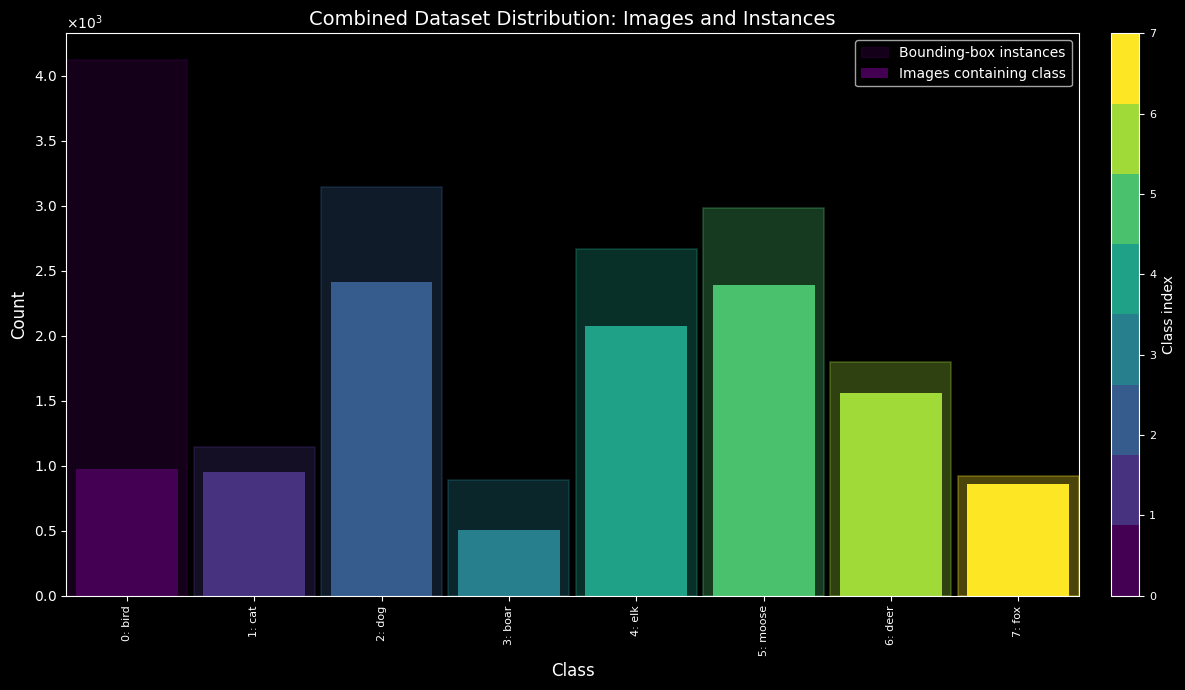

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

n_classes = len(CLASSES)
class_indices = np.arange(n_classes)

instance_values = np.array([
    instance_counts[class_id]
    for class_id in class_indices
])

image_values = np.array([
    image_counts[class_id]
    for class_id in class_indices
])

plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(12, 7))

# Transparent instance bars behind.
ax.bar(
    class_indices,
    instance_values,
    width=0.95,
    color=class_colors,
    alpha=0.30,
    edgecolor=class_colors,
    linewidth=1.2,
    zorder=1,
)

# Solid image-count bars in front.
ax.bar(
    class_indices,
    image_values,
    width=0.80,
    color=class_colors,
    alpha=1.0,
    edgecolor="none",
    zorder=2,
)

ax.margins(x=0)

ax.set_xlabel("Class", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title(
    "Combined Dataset Distribution: Images and Instances",
    fontsize=14,
)

ax.yaxis.set_major_formatter(
    ticker.ScalarFormatter(useMathText=True)
)
ax.ticklabel_format(
    axis="y",
    style="sci",
    scilimits=(0, 0),
)
ax.yaxis.get_offset_text().set_fontsize(10)

ax.set_xticks(class_indices)
ax.set_xticklabels(
    [f"{idx}: {name}" for idx, name in enumerate(CLASSES)],
    rotation=90,
    fontsize=8,
)

# Legend using the first class color instead of white.
legend_color = class_colors[0]

legend_handles = [
    Patch(
        facecolor=legend_color,
        edgecolor=legend_color,
        alpha=0.30,
        label="Bounding-box instances",
    ),
    Patch(
        facecolor=legend_color,
        edgecolor="none",
        alpha=1.0,
        label="Images containing class",
    ),
]

ax.legend(
    handles=legend_handles,
    loc="upper right",
)

# Color scale outside the plotting axes.
subset_cmap = ListedColormap(class_colors)

sm = plt.cm.ScalarMappable(
    cmap=subset_cmap,
    norm=plt.Normalize(
        vmin=0,
        vmax=n_classes - 1,
    ),
)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    ticks=class_indices,
    fraction=0.035,
    pad=0.03,
)

cbar.set_label("Class index", fontsize=10)
cbar.ax.tick_params(labelsize=8)

fig.tight_layout()
plt.show()

In [18]:
import json
import shutil
import random
import re
from pathlib import Path

seed = 0
random.seed(seed)

dataset_root = Path("datasets")

for split in ["train", "validation", "test"]:
    shutil.rmtree(
        dataset_root / split,
        ignore_errors=True,
    )

    (dataset_root / split / "images").mkdir(
        parents=True,
        exist_ok=True,
    )

    (dataset_root / split / "labels").mkdir(
        parents=True,
        exist_ok=True,
    )

def copy_image_and_label(
    image_path,
    label_path,
    destination_split,
    destination_name,
):

    destination_image_dir = (
        dataset_root
        / destination_split
        / "images"
    )

    destination_label_dir = (
        dataset_root
        / destination_split
        / "labels"
    )

    destination_image_path = (
        destination_image_dir
        / destination_name
    )

    destination_label_path = (
        destination_label_dir
        / Path(destination_name).with_suffix(".txt").name
    )

    shutil.copy2(
        image_path,
        destination_image_path,
    )

    shutil.copy2(
        label_path,
        destination_label_path,
    )

with open(subset_path / "train2017.json") as file:
    coco_train_json = json.load(file)

with open(subset_path / "val2017.json") as file:
    coco_val_json = json.load(file)


coco_train_filenames = {
    image["file_name"]
    for image in coco_train_json["images"]
}

coco_val_filenames = {
    image["file_name"]
    for image in coco_val_json["images"]
}


prepared_coco_filenames = {
    image_path.name
    for image_path in coco_tmp_images.iterdir()
    if image_path.suffix.lower() in {
        ".jpg",
        ".jpeg",
        ".png",
    }
}

prepared_coco_train = sorted(
    prepared_coco_filenames
    & coco_train_filenames
)

prepared_coco_val = sorted(
    prepared_coco_filenames
    & coco_val_filenames
)


# Divide original COCO validation images into validation/test.
rng = random.Random(seed)
rng.shuffle(prepared_coco_val)

n_coco_validation = len(prepared_coco_val) // 2

coco_validation_filenames = set(
    prepared_coco_val[:n_coco_validation]
)

coco_test_filenames = set(
    prepared_coco_val[n_coco_validation:]
)


coco_split_counts = {
    "train": 0,
    "validation": 0,
    "test": 0,
}


for filename in sorted(prepared_coco_filenames):

    image_path = coco_tmp_images / filename

    label_path = (
        coco_tmp_labels
        / Path(filename).with_suffix(".txt").name
    )

    if not label_path.exists():
        continue

    if filename in coco_train_filenames:
        destination_split = "train"

    elif filename in coco_validation_filenames:
        destination_split = "validation"

    elif filename in coco_test_filenames:
        destination_split = "test"

    else:
        raise ValueError(
            f"Could not determine COCO split for {filename}"
        )

    destination_name = f"coco_{filename}"

    copy_image_and_label(
        image_path=image_path,
        label_path=label_path,
        destination_split=destination_split,
        destination_name=destination_name,
    )

    coco_split_counts[destination_split] += 1

wildlife_split_pattern = re.compile(
    r"^.+?_(train|valid|validation|test)_"
)

wildlife_split_counts = {
    "train": 0,
    "validation": 0,
    "test": 0,
}


for image_path in sorted(deer_tmp_image_dir.iterdir()):

    if image_path.suffix.lower() not in {
        ".jpg",
        ".jpeg",
        ".png",
    }:
        continue

    label_path = (
        deer_tmp_label_dir
        / image_path.with_suffix(".txt").name
    )

    if not label_path.exists():
        continue

    match = wildlife_split_pattern.match(
        image_path.name
    )

    if match is None:
        raise ValueError(
            "Wildlife image has no encoded source split: "
            f"{image_path.name}"
        )

    source_split = match.group(1)

    if source_split == "train":
        destination_split = "train"

    elif source_split in {
        "valid",
        "validation",
    }:
        destination_split = "validation"

    elif source_split == "test":
        destination_split = "test"

    else:
        raise ValueError(
            f"Unknown source split {source_split}"
        )

    destination_name = (
        f"wildlife_{image_path.name}"
    )

    copy_image_and_label(
        image_path=image_path,
        label_path=label_path,
        destination_split=destination_split,
        destination_name=destination_name,
    )

    wildlife_split_counts[destination_split] += 1

print("COCO:")
for split, count in coco_split_counts.items():
    print(f"  {split:12s}: {count}")

print("\nWildlife:")
for split, count in wildlife_split_counts.items():
    print(f"  {split:12s}: {count}")

print("\nCombined:")
for split in ["train", "validation", "test"]:

    n_images = len(
        list(
            (dataset_root / split / "images")
            .glob("*")
        )
    )

    print(
        f"  {split:12s}: "
        f"{n_images}"
    )

COCO:
  train       : 4075
  validation  : 80
  test        : 81

Wildlife:
  train       : 6597
  validation  : 486
  test        : 277

Combined:
  train       : 10672
  validation  : 566
  test        : 358


* Copying all `Train` images and labels into folder `datasets`
* Split `Train` set into `train` and `validation` set
* TODO: Use `datasets/Validation` as `test` set

* Define dataset class to init and load data
* Introduce data augmentation 

In [19]:
import torch
from torchvision.transforms import ColorJitter
from PIL import Image
from pathlib import Path

BOX_X_INDICES = [0, 2]  # To extract x1, x2 from (x1, y1, x2, y2)
BOX_Y_INDICES = [1, 3]  # To extract y1, y2 from (x1, y1, x2, y2)

class Dataset(torch.utils.data.Dataset):
    def __init__(self, images_dir, labels_dir, target_image_size, transform=None, data_augmentations=None):
        self.target_image_size = target_image_size
        self.transform = transform
        self.data_augmentations = data_augmentations

        image_paths = []
        label_paths = []

        self.populate(image_paths, images_dir)
        self.populate(label_paths, labels_dir)
   
        def basename(path):
            return Path(path).stem

        image_by_name = {
            basename(path): path
            for path in image_paths
        }
        
        label_by_name = {
            basename(path): path
            for path in label_paths
        }
        
        matching_basenames = sorted(
            image_by_name.keys() & label_by_name.keys()
        )
        
        self.image_paths = [
            image_by_name[name]
            for name in matching_basenames
        ]
        
        self.label_paths = [
            label_by_name[name]
            for name in matching_basenames
        ]

    def populate(self, file_paths, dir):
      for dir_path, dir_names, file_names in os.walk(dir):
          for file_name in file_names:
              file_path = os.path.join(dir_path, file_name)
              file_paths.append(file_path)
      file_paths.sort()

    def __len__(self):
        return len(self.image_paths)

    def extract_ground_truth(self, label_path, image_width, image_height):
        boxes = []
        labels = []
        with open(label_path, 'r') as file:
            for line in file.readlines():
                def scale(center, size, factor):
                    scaled_center = center * factor
                    scaled_size = size * factor
                    half_size = scaled_size / 2
                    return scaled_center - half_size, scaled_center + half_size

                columns = line.strip().split()
                class_id, x_center, y_center, width, height = map(
                    float, columns[:5])
                class_id = int(class_id)

                x_min, x_max = scale(x_center, width, image_width)
                y_min, y_max = scale(y_center, height, image_height)

                boxes.append([x_min, y_min, x_max, y_max])
                labels.append(class_id)

        boxes = torch.tensor(boxes, dtype=torch.float32, device=device)
        labels = torch.tensor(labels, dtype=torch.int64, device=device)

        return boxes, labels

    def crop_boxes(self, image, boxes, labels):
        image_width, image_height = image.size
        boxes[boxes < 0] = 0
        boxes[:, BOX_X_INDICES][boxes[:, BOX_X_INDICES] > image_width] = image_width
        boxes[:, BOX_Y_INDICES][boxes[:, BOX_Y_INDICES] > image_height] = image_height

        box_widths = boxes[:, BOX_X_INDICES[1]] - boxes[:, BOX_X_INDICES[0]]
        box_heights = boxes[:, BOX_Y_INDICES[1]] - boxes[:, BOX_Y_INDICES[0]]

        min_side_length = 5  # pixels
        valid_size = (box_widths >= min_side_length) & (
            box_heights >= min_side_length)

        boxes = boxes[valid_size]
        labels = labels[valid_size]

        return boxes, labels

    def mosaic_augment(self,  image, boxes, labels, index):
        image_width, image_height = image.size

        mosaic_image_size = 2 * self.target_image_size
        mosaic_image_center_y, mosaic_image_center_x = mosaic_image_size // 2, mosaic_image_size // 2

        range_other_images = range(1, len(self)-1)
        indices = np.append(np.array([index]),
                            ([index] + np.random.choice(range_other_images, size=3)) % range_other_images.stop)
        
        black_rgb = (0, 0, 0)
        mosaic_image = Image.new(
            'RGB', (mosaic_image_size, mosaic_image_size), black_rgb)
        mosaic_boxes = []
        mosaic_labels = []
        for corner_idx, idx in enumerate(indices):
            image, boxes, labels = self.extract_image(idx)

            top_left_corner = (
                (corner_idx % 2) * mosaic_image_center_x,
                (corner_idx // 2) * mosaic_image_center_y
            )

            mosaic_image.paste(image, top_left_corner)

            if boxes.numel():
                boxes[:, BOX_X_INDICES] = boxes[:,
                                                BOX_X_INDICES] + top_left_corner[0]
                boxes[:, BOX_Y_INDICES] = boxes[:,
                                                BOX_Y_INDICES] + top_left_corner[1]

                mosaic_boxes.append(boxes)
                mosaic_labels.append(labels)

        if mosaic_boxes:
            mosaic_boxes = torch.cat(mosaic_boxes, dim=0)
            mosaic_labels = torch.cat(mosaic_labels, dim=0)
        else:
            mosaic_boxes = torch.zeros((0, 4))
            mosaic_labels = torch.zeros((0,), dtype=torch.int64)

        return mosaic_image, mosaic_boxes, mosaic_labels

    def scale_and_translate(self, image, boxes, labels, base_scale=1., base_translation=1.):
        image_width, image_height = image.size
        image_shape = np.array([image_width, image_height])
        center =  torch.tensor(image_shape / 2, dtype=boxes.dtype, device=device)

        scale = base_scale * (1. + np.random.uniform(
            -self.data_augmentations.max_scale_variation,
            self.data_augmentations.max_scale_variation
        ))
    
        scaled_shape = scale * image_shape
        max_translation = (base_translation * scaled_shape * self.data_augmentations.max_translate).astype(int)
        translation = torch.stack([
            torch.randint(-max_translation[0].item(), max_translation[0].item() + 1, (1,), device=device),
            torch.randint(-max_translation[1].item(), max_translation[1].item() + 1, (1,), device=device)
        ], dim=0).squeeze().to(boxes.dtype)

        image = transforms.functional.affine(
            image,
            angle=0,
            translate=translation.tolist(),
            scale=scale,
            center=center.tolist(),
            shear=[0.0, 0.0]
        )

        centered_boxes = (boxes.reshape(-1, 2) - center)
        scaled_boxes = centered_boxes * scale + center + translation
        boxes = scaled_boxes.reshape(-1, 4)
        
        boxes, labels = self.crop_boxes(image, boxes, labels)
        
        return image, boxes, labels

    def geometric_augmentation(self, image, boxes):
        image_width, image_height = image.size

        if np.random.random() < self.data_augmentations.horizontal_flip_probability:
            image = transforms.functional.hflip(image)
            boxes[:, BOX_X_INDICES] = image_width - \
                boxes[:, list(reversed(BOX_X_INDICES))]

        if np.random.random() < self.data_augmentations.vertical_flip_probability:
            image = transforms.functional.vflip(image)
            boxes[:, BOX_Y_INDICES] = image_height - \
                boxes[:, list(reversed(BOX_Y_INDICES))]

        return image, boxes

    def resize(self, image, boxes):
        image_width, image_height = image.size

        image = transforms.functional.resize(
            image, (self.target_image_size, self.target_image_size))
        
        resize_scale = torch.tensor([self.target_image_size / image_width,
                                     self.target_image_size / image_height] * 2, device=device)
        
        if boxes.numel() == 0:
            boxes = torch.zeros((0, 4), device=boxes.device, dtype=boxes.dtype)

        boxes = boxes * resize_scale

        return image, boxes

    def extract_image(self, index):
        image = Image.open(self.image_paths[index]).convert("RGB")
        image_width, image_height = image.size

        boxes, labels = self.extract_ground_truth(
            self.label_paths[index], image_width, image_height)
        
        if boxes.ndim == 1:
            boxes = boxes.reshape(-1, 4)
            
        if self.data_augmentations is not None:
           image, boxes = self.geometric_augmentation(image, boxes)
        
        image, boxes = self.resize(image, boxes)
        boxes, labels = self.crop_boxes(image, boxes, labels)

        return image, boxes, labels

    def __getitem__(self, index):
        image, boxes, labels = self.extract_image(index)

        if self.data_augmentations is not None:
            image, boxes, labels = self.scale_and_translate(image, boxes, labels)

            if np.random.random() < self.data_augmentations.mosaic_probability:
                image, boxes, labels = self.mosaic_augment(
                    image, boxes, labels, index)
                image, boxes, labels = self.scale_and_translate(image, boxes, labels, base_scale=2, base_translation=2)
            color_jitter = transforms.ColorJitter(self.data_augmentations.max_brightness_jitter,
                                       self.data_augmentations.max_contrast_jitter,
                                       self.data_augmentations.max_saturation_jitter,
                                       self.data_augmentations.max_hue_jitter)
            image = color_jitter(image)
        
        image, boxes = self.resize(image, boxes)

        boxes, labels = self.crop_boxes(image, boxes, labels)
        
        if self.transform:
           image = self.transform(image)

        return {'image': image, 'boxes': boxes, 'labels': labels}


def collate_fn(batch):
    images = [item['image'] for item in batch]
    boxes = [item['boxes'] for item in batch]
    labels = [item['labels'] for item in batch]

    return {
        'images': torch.stack(images, dim=0),
        'boxes': boxes,
        'labels': labels
    }

In [20]:
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from dataclasses import dataclass
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

seed = 1

if device.type == 'cuda':
    torch.cuda.set_device(0)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

torch.manual_seed(seed)

@dataclass
class DataAugmentations:
    horizontal_flip_probability: float
    vertical_flip_probability: float
    max_brightness_jitter: float
    max_contrast_jitter: float
    max_saturation_jitter: float
    max_hue_jitter: float
    max_translate: float
    max_scale_variation: float
    mosaic_probability: float

target_image_size = 640

data_augmentations = DataAugmentations(horizontal_flip_probability=.5,
                                       vertical_flip_probability=0., # Upside down images are out of distribution
                                       max_brightness_jitter=.5,
                                       max_contrast_jitter=.3, 
                                       max_saturation_jitter=.5, 
                                       max_hue_jitter=.02,
                                       max_translate=0,#.2, # Ratio of image
                                       max_scale_variation=.5,
                                       mosaic_probability=1.) # To place 4 random images in 2x2 grid and crop randomly
              
transform = transforms.Compose([transforms.ToTensor()])

data_root = Path("datasets")
train_root = data_root / "train"
val_root = data_root / "validation"
test_root = data_root / "test"
print(train_root/'images')
train_dataset = Dataset(images_dir=train_root/'images',
                              labels_dir=train_root/'labels',
                              target_image_size=target_image_size,
                              transform=transform,
                              data_augmentations=None)

validation_dataset = Dataset(images_dir=val_root/'images',
                                   labels_dir=val_root/'labels',
                                   target_image_size=target_image_size,
                                   transform=transform,
                                   data_augmentations=None)

test_dataset = Dataset(images_dir=test_root/'images',
                             labels_dir=test_root/'labels',
                             target_image_size=target_image_size,
                             transform=transform,
                             data_augmentations=None)

# Shuffle validation and test set once to get variation when plotting, as opposed to consecutive scan images
shuffled_indices = torch.randperm(len(validation_dataset)).tolist()
validation_dataset = Subset(validation_dataset, shuffled_indices) 
shuffled_indices = torch.randperm(len(test_dataset)).tolist()
test_dataset = Subset(test_dataset, shuffled_indices) 

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)
validation_loader = DataLoader(validation_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn)

Using device: cuda
datasets/train/images


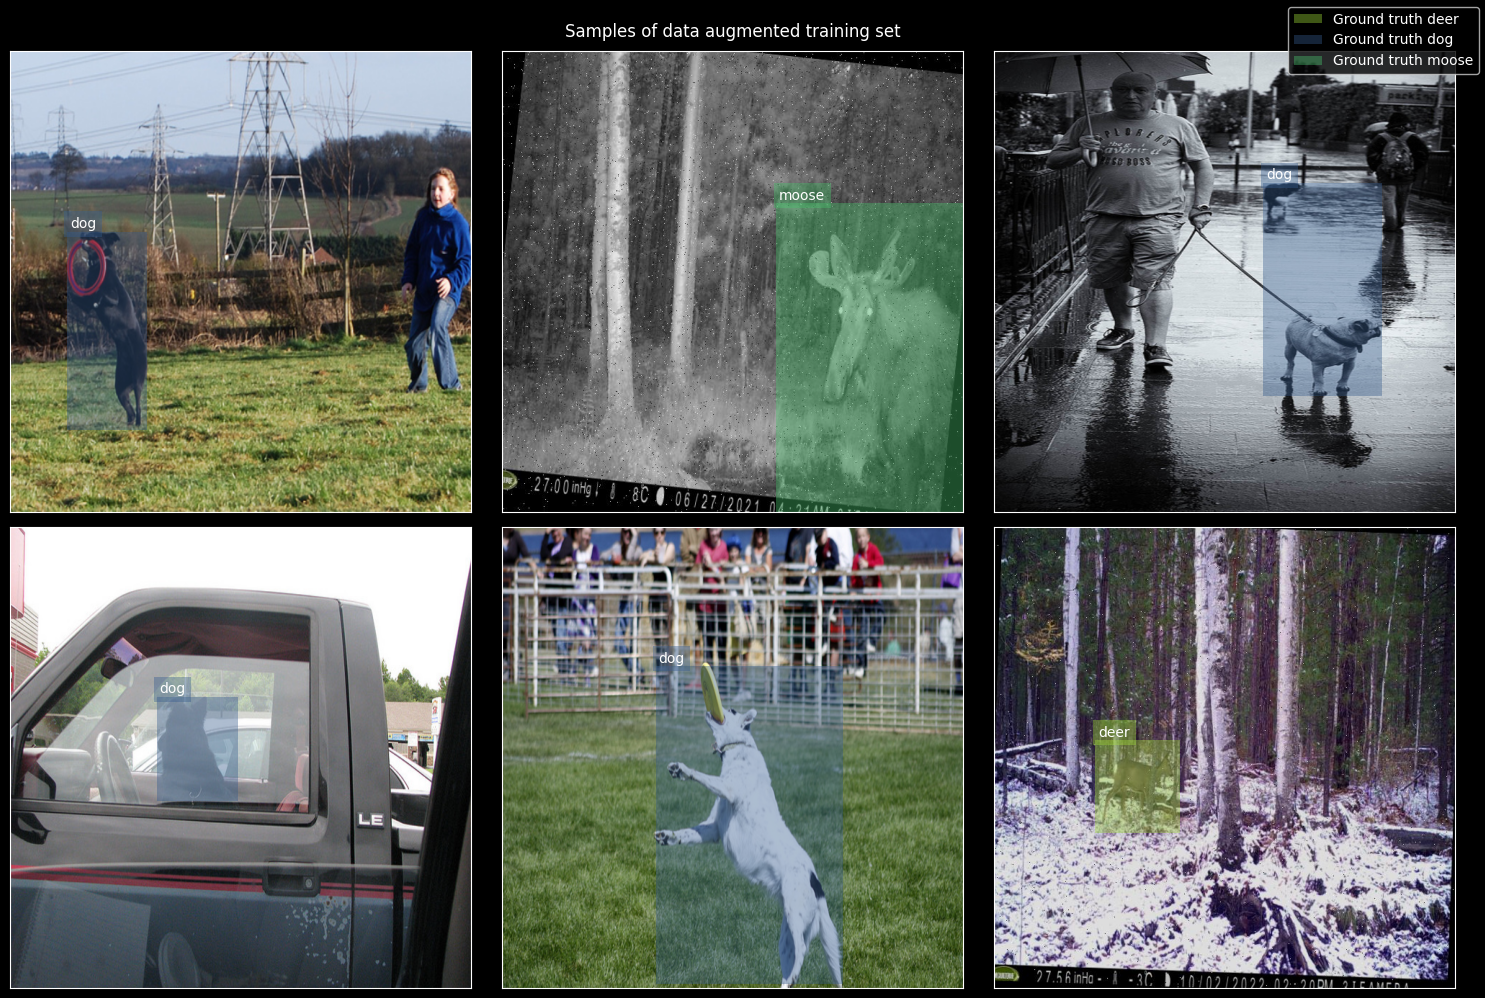

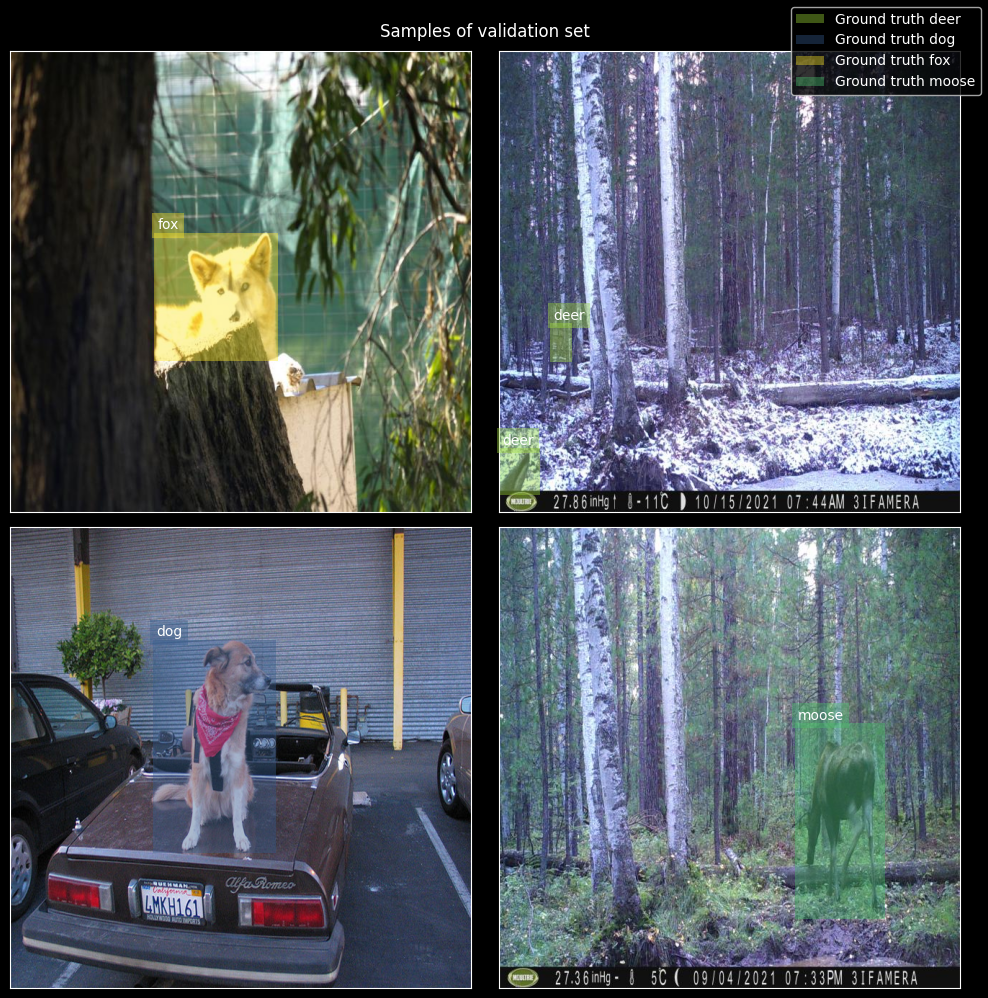

In [21]:
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
from collections import OrderedDict, namedtuple

Boxes = namedtuple("Boxes", ["xyxy", "conf", "cls"]) # To output on same format as Ultralytics detect call 
Prediction = namedtuple("Prediction", ["boxes"])

def plot_boxes(ax, image, boxes, labels, prediction_confidences=None):
    ax.imshow(image)
    
    for i, label in enumerate(labels):
        x_min, y_min, x_max, y_max = boxes[i]
        width, height = x_max - x_min, y_max - y_min

        class_label = CLASSES[int(label)]
        class_color = class_colors[int(label)]

        legend = class_label
        transparency = .4
        line_width= 3
        bounding_box = plt.Rectangle((x_min, y_min),
                                     width, height,
                                     linewidth=line_width,
                                     label=legend)
        label_text = ax.text(x_min+4, y_min-5, class_label, clip_on=False)
        label_text.set_bbox(dict(facecolor=to_rgba(class_color, alpha=transparency)))
        
        if prediction_confidences is not None:
            label_text.set_position((x_max - 4, y_max + 4))
            label_text.set_horizontalalignment('right')
            label_text.set_verticalalignment('top')
        
            confidence_label = f'\nconfidence: {prediction_confidences[i]:.2f}'
        
            bounding_box.set_edgecolor(class_color)
            bounding_box.set_facecolor('none')
            bounding_box.set_label('Predicted ' + legend)
        
            label_text.set_text(class_label + confidence_label)
        
            label_box = label_text.get_bbox_patch()
            label_box.set_edgecolor(class_color)
            label_box.set_facecolor('none')
            label_box.set_linewidth(line_width)
        else:
            bounding_box.set_label('Ground truth ' + legend)
            bounding_box.set_edgecolor('none')
            bounding_box.set_facecolor(to_rgba(class_color, alpha=transparency))
            label_box = label_text.get_bbox_patch()
            label_box.set_edgecolor('none')
            
        ax.set_xticks([])
        ax.set_yticks([])
        ax.add_patch(bounding_box)


def add_legends(fig):
    box_legends = [ax.get_legend_handles_labels() for ax in fig.axes]
    box_legends, labels = [sum(box_legend, []) for box_legend in zip(*box_legends)]
    box_legends = sorted(zip(labels, box_legends), key=lambda x: x[0])  # Sort by label
    if box_legends:
        labels, box_legends = zip(*box_legends)
        box_labeled_legends = OrderedDict(zip(labels, box_legends))
        fig.legend(box_labeled_legends.values(), box_labeled_legends.keys())


def visualize_data_samples(title, batch, predictions=None):
      n_samples = len(batch['images'])
      n_columns = int(min(np.ceil(np.sqrt(n_samples)), 3))
      n_rows = int(min(np.ceil(n_samples / n_columns), 3 if predictions else 2))
      fig, axes = plt.subplots(n_rows, n_columns, figsize=(5*n_columns, 5*n_rows))

      if isinstance(axes, plt.Axes):  
          axes = [axes]
      else:
          axes = axes.flatten() # Handle 1 subplot
          
      plt.suptitle(title)
      n_samples = min(n_rows * n_columns, n_samples)

      for i in range(n_samples):
          image = batch['images'][i].permute(1, 2, 0).cpu().numpy()
          boxes = batch['boxes'][i].detach().cpu().numpy()
          labels = batch['labels'][i]
          plot_boxes(axes[i], image, boxes, labels)
          plt.tight_layout()
          
      if predictions is not None:
          for i in range(min(n_samples, len(predictions))):
              prediction = predictions[i]
              if i > n_samples:
                  break
              if prediction.boxes.xyxy.numel() == 0:
                  continue
                  
              image = batch['images'][i].permute(1, 2, 0).cpu().numpy()
              boxes = prediction.boxes.xyxy.detach().cpu().numpy()
              confidences = prediction.boxes.conf.detach().cpu().numpy()
              classes = prediction.boxes.cls.detach().cpu().numpy()
              plot_boxes(axes[i], image, boxes, classes, confidences)

      add_legends(fig)
      plt.show()

training_batch = next(iter(train_loader))
visualize_data_samples('Samples of data augmented training set', training_batch)
validation_batch = next(iter(validation_loader))
visualize_data_samples('Samples of validation set', validation_batch)

In [23]:
import yaml, os, logging
import torch.optim as optim
from torch.optim.lr_scheduler import OneCycleLR, LambdaLR
from shutil import copy2

n_epochs = 100
patience=10
root='datasets'

# verbose=False and export YOLO_VERBOSE=False alone does silence verbose output
def supress_output():
    os.environ["TQDM_DISABLE"]      = "1"
    os.environ["YOLO_DISABLE_TQDM"] = "1"
    os.environ["YOLO_VERBOSE"]      = "False"
    logging.getLogger("ultralytics").setLevel(logging.CRITICAL)

supress_output()

# Comparing with Ultralytics model
# Jocher, G. (2020). YOLOv5 by Ultralytics (Version 7.0) [Computer software]. https://doi.org/10.5281/zenodo.3908559 [Computer software]. http://github.com/ultralytics/yolov5
!pip install ultralytics > /dev/null
from ultralytics import YOLO

#!rm runs -rf
yolo26n = YOLO('yolo26n.pt')
n_params = sum(p.numel() for p in yolo26n.model.parameters())
print(f"Number of parameters: {n_params:.3e}")

root = Path("datasets").resolve()

data_yaml = root / "data.yaml"

data = {
    "path": str(root),
    "train": "train/images",
    "val": "validation/images",
    "test": "test/images",
    "names": {
        index: name
        for index, name in enumerate(CLASSES)
    },
}

with open(data_yaml, "w") as file:
    yaml.safe_dump(data, file, sort_keys=False)


results = yolo26n.train(
    data=str(data_yaml),
    epochs=n_epochs,
    imgsz=target_image_size,
    batch=train_loader.batch_size,
    device=device,

    # Training control
    patience=patience,
    optimizer="auto",
    cos_lr=True,

    # Augmentation
    mosaic=0.7,
    close_mosaic=15,
    fliplr=0.5,
    flipud=0.0,
    scale=0.35,
    translate=0.10,

    # Avoid extremely destructive color changes
    hsv_h=0.015,
    hsv_s=0.5,
    hsv_v=0.35,

    pretrained=True,
    freeze=10,
)


Number of parameters: 2.572e+06


`get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.


Calculate evaluation metrics
* Confusion matrix
* Precision
* Recall
* F1 score
* Best confidence threshold

Validation data set evaluation:
Using confidence threshold = argmax(f1_scores) = 0.50
Test data set evaluation:


Precision: 0.8833, 
Recall: 0.7433, 
F1 score: 0.8073


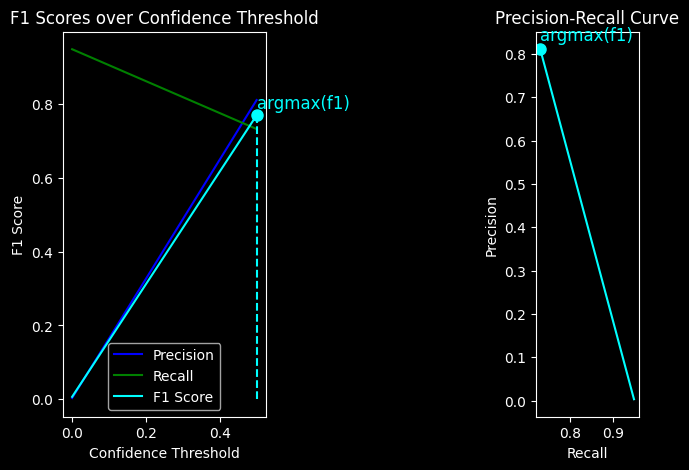

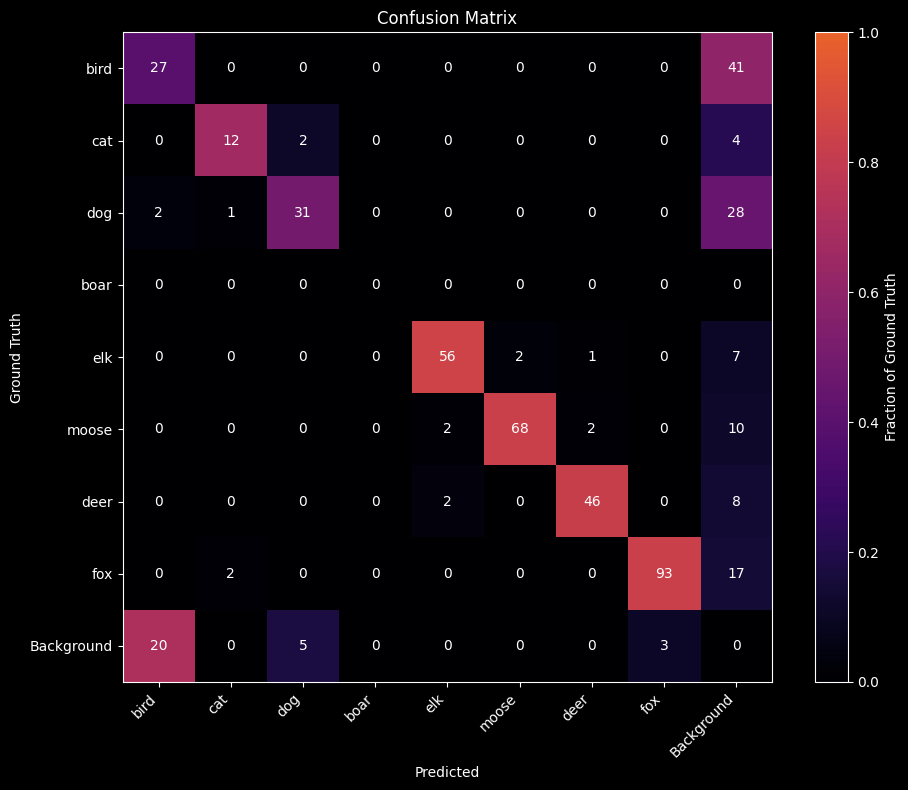

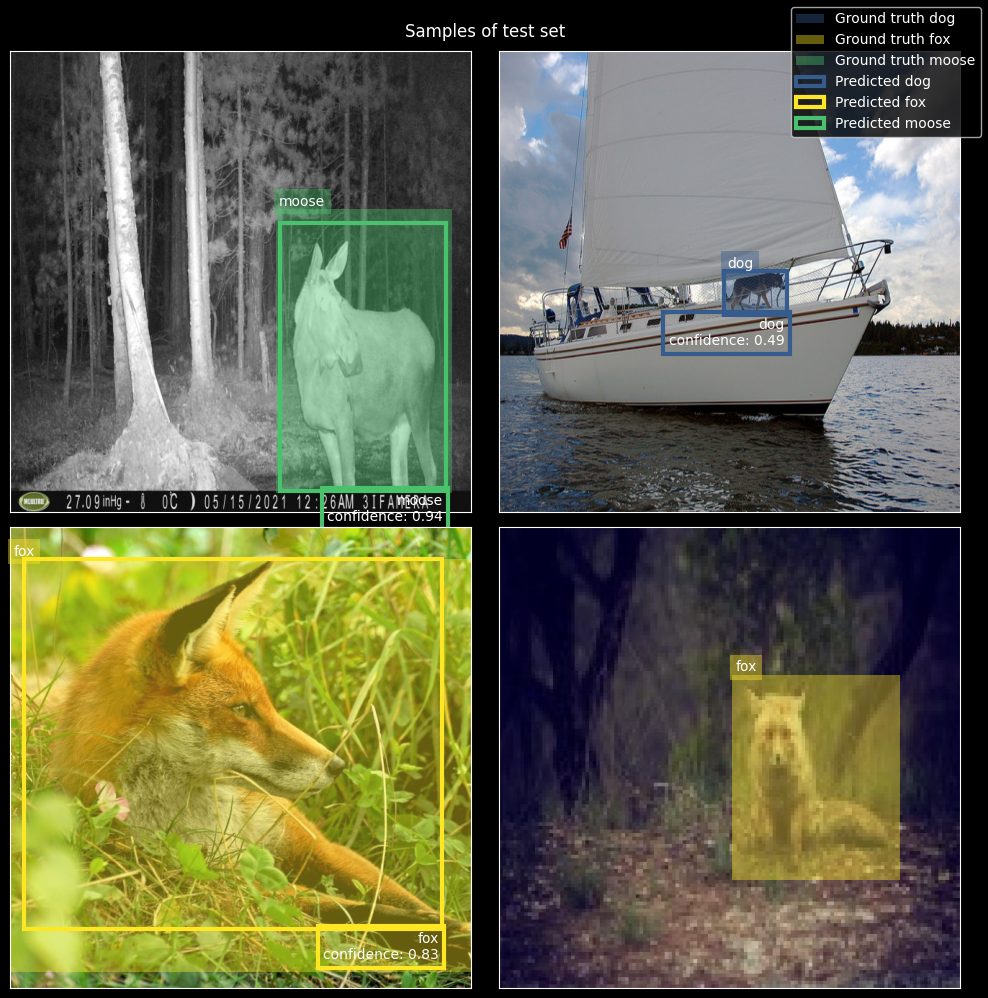

In [24]:
from matplotlib.colors import LinearSegmentedColormap
from scipy.optimize import linear_sum_assignment
from torchvision.ops import box_iou

def plot_confusion_matrix(confusion_matrix):
    fig, ax = plt.subplots(figsize=(10, 8))

    # Normalize rows only for color scaling.
    row_sums = confusion_matrix.sum(axis=1, keepdims=True)
    normalized_confusion_matrix = np.divide(
        confusion_matrix,
        row_sums,
        out=np.zeros_like(confusion_matrix, dtype=float),
        where=row_sums != 0
    )

    cmap = plt.get_cmap('inferno')
    colors = cmap(np.linspace(0., .65, cmap.N // 2))
    heatmap = LinearSegmentedColormap.from_list('Upper Half', colors)

    im = ax.imshow(
        normalized_confusion_matrix,
        interpolation='nearest',
        cmap=heatmap,
        vmin=0.0,
        vmax=1.0
    )

    ax.set_title('Confusion Matrix')

    colorbar = fig.colorbar(im, ax=ax)
    colorbar.set_label('Fraction of Ground Truth')

    tick_marks = np.arange(n_evaluation_classes)

    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)

    ax.set_xticklabels(
        EVALUATION_CLASSES,
        rotation=45,
        ha='right'
    )
    ax.set_yticklabels(EVALUATION_CLASSES)

    # Print raw counts, not normalized values.
    for i in range(n_evaluation_classes):
        for j in range(n_evaluation_classes):
            ax.text(
                j,
                i,
                confusion_matrix[i, j],
                ha='center',
                va='center',
                color='white'
            )

    ax.set_ylabel('Ground Truth')
    ax.set_xlabel('Predicted')

    fig.tight_layout()
    plt.show()
    
def plot_scores(confidence_thresholds, precisions, recalls, f1_scores, f1_argmax, best_confidence_threshold):
    n_rows, n_columns = 1, 2
    fig, axes = plt.subplots(n_rows, n_columns, figsize=(5*n_columns, 5*n_rows))
    
    ax0 = axes[0]
    ax0.plot(confidence_thresholds, precisions, color='blue', label='Precision')
    ax0.plot(confidence_thresholds, recalls, color='green', label='Recall')
    ax0.plot(confidence_thresholds, f1_scores, color='cyan', label='F1 Score')
    ax0.set_aspect('equal')
    ax0.set_xlabel('Confidence Threshold')
    ax0.set_ylabel('F1 Score')
    ax0.set_title('F1 Scores over Confidence Threshold')
    ax0.plot(best_confidence_threshold, f1_scores[f1_argmax], color='cyan', marker='o', markersize=8)
    ax0.plot([best_confidence_threshold, best_confidence_threshold], [0, f1_scores[f1_argmax]], color='cyan', linestyle='dashed')
    ax0.text(best_confidence_threshold, f1_scores[f1_argmax]+.02, 'argmax(f1)' , color='cyan', fontsize=12)
    ax0.legend()

    ax1 = axes[1]
    ax1.plot(recalls, precisions, color='cyan')
    ax1.plot(recalls[f1_argmax],
             precisions[f1_argmax],
             color='cyan', marker='o', markersize=8)
    ax1.text(recalls[f1_argmax],
             precisions[f1_argmax]+.02,
             'argmax(f1)', color='cyan', fontsize=12)
    ax1.set_aspect('equal')
    ax1.set_xlabel('Recall')
    ax1.set_ylabel('Precision')
    ax1.set_title('Precision-Recall Curve')

def evaluate_over_confidences(confidence_thresholds, data_set, model):
    precisions, recalls, f1_scores = [], [], []
    
    for confidence_threshold in confidence_thresholds:
        precision, recall, f1_score, confusion_matrix = evaluate_metrics(model=model,
                                                                        data_set=data_set,
                                                                        confidence_threshold=confidence_threshold)        
        precisions.append(precision)
        recalls.append(recall)
        f1_scores.append(f1_score)
        
    return precisions, recalls, f1_scores
    
def calculate_scores(true_positives, false_positives, false_negatives):
    epsilon = 1e-6

    precision = true_positives / (true_positives + false_positives + epsilon)
    recall = true_positives / (true_positives + false_negatives + epsilon)
    f1_score = 2 * precision * recall / (precision + recall + epsilon)

    return precision, recall, f1_score

def calculate_metrics(predicted_boxes, predicted_labels, true_boxes, true_labels):
    iou_matrix = box_iou(true_boxes, predicted_boxes)
    cost_matrix = 1 - iou_matrix.cpu().numpy()
    ground_truth_indices, prediction_indices = linear_sum_assignment(cost_matrix)

    confusion_matrix = np.zeros((n_evaluation_classes, n_evaluation_classes), dtype=int)
    class_keys = class_indices
    
    matched_true_boxes = set()
    matched_predicted_boxes = set()

    for gt_idx, predicted_idx in zip(ground_truth_indices, prediction_indices):
        iou = iou_matrix[gt_idx, predicted_idx]
        if iou >= iou_threshold:
            true_label = int(true_labels[gt_idx].item())
            predicted_label = int(predicted_labels[predicted_idx].item())
            confusion_matrix[true_label, predicted_label] += 1
            matched_true_boxes.add(gt_idx)
            matched_predicted_boxes.add(predicted_idx)
        else:
            predicted_label = int(predicted_labels[predicted_idx].item())
            confusion_matrix[BACKGROUND_INDEX, predicted_label] += 1
            matched_predicted_boxes.add(predicted_idx)

    unmatched_predicted_indices = set(range(len(predicted_boxes))) - matched_predicted_boxes
    for predicted_idx in unmatched_predicted_indices:
        predicted_label = int(predicted_labels[predicted_idx].item())
        confusion_matrix[BACKGROUND_INDEX, predicted_label] += 1

    unmatched_gt_indices = set(range(len(true_boxes))) - matched_true_boxes
    for gt_idx in unmatched_gt_indices:
        true_label = int(true_labels[gt_idx].item())
        confusion_matrix[true_label, BACKGROUND_INDEX] += 1

    return confusion_matrix


def evaluate_metrics(model, data_set, confidence_threshold):
    with torch.no_grad():
        confusion_matrix = np.zeros(
            (n_evaluation_classes, n_evaluation_classes),
            dtype=int
        )

        for batch in data_set:
            images = batch['images'].to(device)

            ground_truth_boxes = batch['boxes']
            ground_truth_labels = batch['labels']

            predictions = model.predict(
                images,
                conf=confidence_threshold
            )

            for i, prediction in enumerate(predictions):
                predicted_boxes = prediction.boxes.xyxy
                predicted_classes = prediction.boxes.cls

                batch_confusion_matrix = calculate_metrics(
                    predicted_boxes,
                    predicted_classes,
                    ground_truth_boxes[i].to(device),
                    ground_truth_labels[i].to(device)
                )

                confusion_matrix += batch_confusion_matrix

        true_positives = np.sum(
            np.diag(
                confusion_matrix[
                    :BACKGROUND_INDEX,
                    :BACKGROUND_INDEX
                ]
            )
        )

        false_positives = (
            np.sum(confusion_matrix[:, :BACKGROUND_INDEX])
            - true_positives
        )

        false_negatives = np.sum(
            confusion_matrix[:BACKGROUND_INDEX, BACKGROUND_INDEX]
        )

        precision, recall, f1_score = calculate_scores(
            true_positives,
            false_positives,
            false_negatives
        )

        return precision, recall, f1_score, confusion_matrix

best_yolo5_models = !find runs -name best.pt | sort
best_model = YOLO(best_yolo5_models[-1])
best_model.eval()
confidence_thresholds = np.arange(0., 1., .05)
iou_threshold = .5

precisions, recalls, f1_scores = evaluate_over_confidences(confidence_thresholds, data_set=validation_loader, model=best_model)   
f1_argmax = np.argmax(f1_scores)
best_confidence_threshold = confidence_thresholds[f1_argmax]

plot_scores(confidence_thresholds, precisions, recalls, f1_scores, f1_argmax, best_confidence_threshold)
print(f"Validation data set evaluation:\nUsing confidence threshold = argmax(f1_scores) = {best_confidence_threshold:.2f}")

precision, recall, f1_score, confusion_matrix = evaluate_metrics(best_model, test_loader, best_confidence_threshold)
print(f"Test data set evaluation:\n\n")
print(f"Precision: {precision:.4f}, \nRecall: {recall:.4f}, \nF1 score: {f1_score:.4f}")

plot_confusion_matrix(confusion_matrix)           

test_batch = next(iter(test_loader))
best_model.conf = best_confidence_threshold
predictions = best_model.predict(test_batch['images'].to(device), verbose=False)
visualize_data_samples('Samples of test set', test_batch, predictions)

Next steps:
* Improve hyper parameter search for better performance
* Pre-train model on other dataset
* Unit test code